## Plot single trial behavior and outcomes in example sessions
As in Fig. 1 and Extended Data Fig. 1.
(From locally saved dataframes)

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm

In [3]:
subject = 'wilbur'
date = '20210408'
file_name = subject+date
fig_dir = '/home/stelmo/xulu/plots/behavior/'
results_dir = '/home/xulu/code/results/'
data_dir = '/home/xulu/code/MetaLearningDynamics/example_data/'
behav_model_fits = pd.read_pickle(data_dir+file_name+"_behav_model_fits.pkl")

In [4]:
def plot_grid_dots_example(dataframe, subject_id, figsize=(20,8), show_switches=True, is_decay=False,
                        show_switch_arrows_top=False, show_switch_arrows_bottom=False,
                        plot_date=None, epochs=None, max_n_trials=None, min_n_trials=0,
                        save_fig=False, fig_path='', aspect_ratio_sq=True,
                        dot_size=70, dot_line_thickness=2.5, color_map = {'A': 'green', 'B': 'darkblue', 'C': 'mediumorchid'}):
    '''plot example epoch single-trial reward outcomes with annotations.'''
    '''the epochs to be plotted are selected before calling this function'''
    
    if dataframe.empty:
        print("No data matches the provided criteria.")
        return
    
    # Filter by num trials
    if max_n_trials:
        dataframe = dataframe.iloc[min_n_trials:max_n_trials]

    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    if aspect_ratio_sq:
        ax.set_aspect('equal')  # Ensure equal aspect ratio

    # Draw the light grey grid lines
    for x in np.arange(0, len(dataframe)+1):
        ax.axvline(x, ymin=0, ymax=0.85, color='lightgrey', linewidth=0.177, zorder=0)  # vertical lines with adjusted ymax ymax 5.5
        # plt.vline(x, ymin=0, ymax=5.5, color='lightgrey', linewidth=0.5, zorder=0)  
    for y in np.arange(0, 7):
        ax.axhline(y, color='lightgrey', linewidth=0.177, zorder=0)  # horizontal lines

    # Detecting epoch, contingency changes, and pathc (stem) switches
    for i in range(1, len(dataframe)):
        if dataframe['epoch'].iloc[i] != dataframe['epoch'].iloc[i-1]:
            ax.axvline(i, color='black', linewidth=2)
        if (dataframe['contingency'].iloc[i] != dataframe['contingency'].iloc[i-1]) & (not is_decay):
            ax.axvline(i, color='black', linewidth=1, linestyle='-')
        if show_switches and dataframe['stem'].iloc[i] != dataframe['stem'].iloc[i-1]:
            ax.axvline(i, ymax=0.85, color='red', linewidth=.25)
        if show_switch_arrows_top and dataframe['stem'].iloc[i] != dataframe['stem'].iloc[i-1]:
            ax.plot(i, 6.5, 'v', color='red', markersize=7,markeredgewidth=0.36) #6.5
        if show_switch_arrows_bottom and dataframe['stem'].iloc[i] != dataframe['stem'].iloc[i-1]:
            ax.plot(i, -.5, '^', color='red', markersize=6) #-.5

    # Plot each trial as a circle
    for i, (index, row) in enumerate(dataframe.iterrows()):
        # edgecolor = color_map[row['stem']]
        edgecolor = color_map[row['leaf']]
        facecolor = edgecolor if row['reward'] == 1 else 'white'  # Filled if rewarded
        ax.scatter(i + 0.5, row['leaf'] - 0.5, color=facecolor, edgecolor=edgecolor, s=dot_size, linewidth=dot_line_thickness)

    # Remove ticks
    #ax.tick_params(left=False, bottom=False, labelleft=True, labelbottom=False)

    # Adjust labels and styles
    ax.set_yticks(np.arange(0.5,6.5))
    ax.set_yticklabels(np.arange(1, 7), fontsize=10)
    ax.set_ylabel('Port', fontsize=20)
    ax.set_xlabel('Trial', fontsize=20)
    ax.set_xticks(range(0,len(dataframe),20), range(0,len(dataframe),20), fontsize=15)
    ax.set_title(f'{plot_date} epoch{epochs}', fontsize=20)
    
    ax.set_xlim(0, len(dataframe))
    ax.set_ylim(0, 7) # Adjusting the ylim to make room for the patch-switch triangles at the top
    plt.tight_layout()

    # Adjust plot outline color
    for spine in ax.spines.values():
        spine.set_edgecolor('lightgrey')
        spine.set_linewidth(0.177)
    ax.spines['top'].set_visible(False)

    
    if save_fig:
        fig_name = f'{subject_id}_{plot_date}_epoch{epochs}_{min_n_trials}_{max_n_trials}_{show_switches}_{show_switch_arrows_top}_{show_switch_arrows_bottom}_{figsize[0]}_{figsize[1]}_{aspect_ratio_sq}'
        plt.savefig(f'{fig_path}{fig_name}.pdf', format='pdf', bbox_inches="tight", pad_inches=.5, dpi=300)       
        
    plt.show()

### Plot single-trial behavior history of example sessions

202080208050


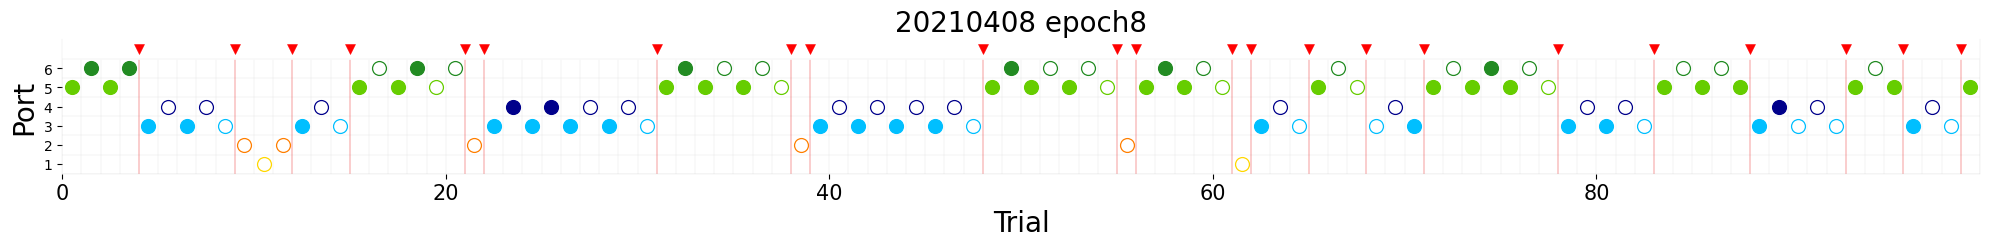

In [5]:
contingencies = np.array(behav_model_fits[behav_model_fits.trial_number_by_epoch==0].contingency)
epoch = 8
behav_one_epoch = behav_model_fits[behav_model_fits.epoch == epoch]
print(contingencies[epoch//2-1]) # Print the port reward probabilities of a selected epoch
colors = cm.Paired(np.linspace(0,1,12))
# color_map = {'A': colors[7,:], 'B': colors[1,:], 'C': colors[3,:]} # Use this color map when plotting patches
color_map = {1: '#FFD700', 2: '#FF7F00', 3: '#00BFFF',4: '#00008B', 5: '#66CD00', 6: '#228B22'} # Use this color map when plotting ports
plot_grid_dots_example(dataframe=behav_one_epoch, subject_id=subject, figsize=(20,15), plot_date = date, epochs = epoch, dot_size=100,dot_line_thickness=0.9,\
                       min_n_trials=0, max_n_trials = 100, save_fig = False, fig_path = fig_dir, show_switches = True, show_switch_arrows_top=True,\
                       color_map = color_map, is_decay = True)
